In [1]:
import sys
from datetime import datetime

from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm


sys.path.append("../")
from xThreat import xThreat

# Introduction

The goal of this notebook is to find what maximal error is acceptable. This is done by looking at the Euros 2020 data set that is openly available.
<br><br>
This data is used to obtain the action ratings by the Expected Threat model. The xT values are then distorded by adding noise with a maximal error. The maximal error for which less than 10% of all in-game players changes a quartile is found.

## Calculate player minutes per position

### Extract lineups from sb

In [2]:
# Liguea 1 has competition_id = 7
competition_id = 7
# Season 2015/2016 has season_id = 27
season_id = 27

# Get the matches for Ligue 1 2015/2016
Ligue_1_season_1516 = sb.matches(competition_id=competition_id, season_id=season_id)

In [3]:
# time_played_per_position = {}

# match_id = Ligue_1_season_1516.iloc[0]['match_id']
# lineups_dict = sb.lineups(match_id)
# lineups = [lineups_dict[key] for key in lineups_dict.keys()]

In [4]:
# # Only get the Half Ends:
# raw_events = sb.events(match_id=match_id)
# half_ends = raw_events[raw_events['type'] == 'Half End'].sort_values(['period', 'timestamp'])
# half_ends

In [5]:
# # Only get the Half Ends:
# raw_events = sb.events(match_id=match_id)
# half_ends = raw_events[raw_events['type'] == 'Half End']
# half_ends

# # Get the length of both halves
# half_1_length = half_ends.iloc[0]['timestamp']
# hh, mm, ss = half_1_length.split(':')
# half_1_length_minutes = int(hh) * 60 + int(mm) + float(ss) / 60

# half_2_length = half_ends.iloc[-1]['timestamp']
# hh, mm, ss = half_2_length.split(':')
# half_2_length_minutes = int(hh) * 60 + int(mm) + float(ss) / 60

# print(f"Half 1 length: {half_1_length_minutes} minutes")
# print(f"Half 2 length: {half_2_length_minutes} minutes")

In [6]:
def timestamp_to_minutes(timestamp: str, format = "hh:mm:ss") -> float:
    if timestamp is None:
        return None
    elif format == "hh:mm:ss":
        hh, mm, ss = timestamp.split(':')
        return int(hh) * 60 + int(mm) + float(ss) / 60
    elif format == "mm:ss":
        mm, ss = timestamp.split(':')
        return int(mm) + float(ss) / 60

In [7]:
# # Only get the Half Ends:
# raw_events = sb.events(match_id=match_id)
# half_ends = raw_events[raw_events['type'] == 'Half End']
# half_ends

# # Get the length of both halves
# half_1_length_minutes = timestamp_to_minutes(half_ends.iloc[0]['timestamp'], format="hh:mm:ss")
# half_2_length_minutes = timestamp_to_minutes(half_ends.iloc[-1]['timestamp'], format="hh:mm:ss")

# print(f"Half 1 length: {half_1_length_minutes} minutes")
# print(f"Half 2 length: {half_2_length_minutes} minutes")

In [8]:
time_played_per_position = {}

for match_id in tqdm(Ligue_1_season_1516['match_id'].tolist()):
    # Get the length of both halves
    raw_events = sb.events(match_id=match_id)
    half_ends = raw_events[raw_events['type'] == 'Half End'].sort_values(['period', 'timestamp'])
    half_1_length_minutes = timestamp_to_minutes(half_ends.iloc[0]['timestamp'], format="hh:mm:ss")
    half_2_length_minutes = timestamp_to_minutes(half_ends.iloc[-1]['timestamp'], format="hh:mm:ss")

    # Get the lineups
    lineups_dict = sb.lineups(match_id)
    lineups = [lineups_dict[key] for key in lineups_dict.keys()]

    # Iterate over the lineups
    for lineup in lineups:
        for idx, player in lineup.iterrows():

            # Get player ID
            player_id = player['player_id']
            
            # Iterate over the positions played by the player
            for position_data in player['positions']:
                # Get position and time data
                position = position_data['position']
                start_minute = timestamp_to_minutes(position_data['from'], format="mm:ss")
                end_minute = timestamp_to_minutes(position_data['to'], format="mm:ss")
                start_period = position_data['from_period']
                end_period = position_data['to_period']

                # If playing till the end of the match, None is given, so set to half 2 length
                if end_minute is None and end_period is None:
                    end_period = 2
                    end_minute = half_2_length_minutes + 45

                # Calculate minutes played based on periods
                if start_period == 1 and end_period == 1:
                    minutes_played = end_minute - start_minute
                elif start_period == 1 and end_period == 2:
                    # Minutes played is minutes first half + minutes second half
                    # Note: start of 2nd half is not consistend between the two formats
                    minutes_played = (half_1_length_minutes - start_minute) + (end_minute - 45)

                elif start_period == 2 and end_period == 2:
                    minutes_played = end_minute - start_minute
                else:
                    print(f"Player ID: {player_id}, Position: {position} in match {match_id} had unexpected period values:")
                    print(f"starting from period {start_period} timestamp {start_minute}, ending at period {end_period} timestamp {end_minute}")
                    # raise ValueError("Unexpected period values")
                
                # Accumulate time played per position
                time_played = end_minute - start_minute
                if (player_id, position) not in time_played_per_position:
                    time_played_per_position[(player_id, position)] = time_played
                else:
                    time_played_per_position[(player_id, position)] += time_played        


 35%|███▌      | 133/377 [01:48<03:07,  1.30it/s]

Player ID: 3230, Position: Center Forward in match 3829416 had unexpected period values:
starting from period 2 timestamp 45.05, ending at period 1 timestamp 46.083333333333336
Player ID: 16462, Position: Right Wing Back in match 3829416 had unexpected period values:
starting from period 2 timestamp 45.05, ending at period 1 timestamp 46.083333333333336


100%|██████████| 377/377 [05:11<00:00,  1.21it/s]


In [9]:
# Convert to DataFrame for easier analysis
df_time_played = pd.DataFrame.from_dict(time_played_per_position, orient='index', columns=['minutes_played'])
df_time_played.index = pd.MultiIndex.from_tuples(df_time_played.index, names=['player_id', 'position'])
df_time_played = df_time_played.reset_index()
df_time_played

,player_id,position,minutes_played
0,2985,Right Wing,0.450000
1,2985,Left Wing,207.350550
2,2985,Left Midfield,216.835033
3,2990,Left Defensive Midfield,1298.928100
4,2990,Right Center Midfield,223.179167
...,...,...,...
3048,4417,Left Wing Back,0.166667
3049,4417,Center Forward,21.567517
3050,10746,Left Wing Back,21.567517
3051,3951,Left Defensive Midfield,64.683333


In [10]:
df_time_played.value_counts('position')

position
Center Attacking Midfield    246
Right Wing                   224
Left Wing                    218
Left Center Midfield         193
Right Center Midfield        192
Center Forward               181
Left Midfield                176
Right Midfield               173
Right Defensive Midfield     165
Left Defensive Midfield      161
Right Center Forward         141
Right Back                   134
Center Defensive Midfield    131
Left Center Forward          131
Right Center Back            130
Left Center Back             121
Left Back                    116
Right Wing Back               51
Left Wing Back                51
Goalkeeper                    46
Center Back                   32
Right Attacking Midfield      21
Left Attacking Midfield       19
Name: count, dtype: int64

In [11]:
df_time_played[df_time_played['minutes_played'] >= 300].value_counts('position')

position
Right Center Back            57
Right Back                   51
Left Back                    51
Left Center Back             49
Center Forward               47
Right Wing                   39
Right Defensive Midfield     38
Goalkeeper                   35
Left Defensive Midfield      35
Left Wing                    35
Center Attacking Midfield    31
Center Defensive Midfield    30
Right Center Midfield        27
Left Center Midfield         26
Left Midfield                22
Right Midfield               20
Left Center Forward          18
Right Center Forward         17
Left Wing Back                4
Center Back                   3
Left Attacking Midfield       2
Right Wing Back               2
Right Attacking Midfield      1
Name: count, dtype: int64

## Filter on position

In [12]:
# Give position to filter on
position_filter = 'Center Forward'

In [13]:
df_time_played ['position'].value_counts()

position
Center Attacking Midfield    246
Right Wing                   224
Left Wing                    218
Left Center Midfield         193
Right Center Midfield        192
Center Forward               181
Left Midfield                176
Right Midfield               173
Right Defensive Midfield     165
Left Defensive Midfield      161
Right Center Forward         141
Right Back                   134
Left Center Forward          131
Center Defensive Midfield    131
Right Center Back            130
Left Center Back             121
Left Back                    116
Left Wing Back                51
Right Wing Back               51
Goalkeeper                    46
Center Back                   32
Right Attacking Midfield      21
Left Attacking Midfield       19
Name: count, dtype: int64

In [14]:
df_time_played[df_time_played['minutes_played'] >= 300].value_counts('position')

position
Right Center Back            57
Right Back                   51
Left Back                    51
Left Center Back             49
Center Forward               47
Right Wing                   39
Right Defensive Midfield     38
Goalkeeper                   35
Left Defensive Midfield      35
Left Wing                    35
Center Attacking Midfield    31
Center Defensive Midfield    30
Right Center Midfield        27
Left Center Midfield         26
Left Midfield                22
Right Midfield               20
Left Center Forward          18
Right Center Forward         17
Left Wing Back                4
Center Back                   3
Left Attacking Midfield       2
Right Wing Back               2
Right Attacking Midfield      1
Name: count, dtype: int64

Number of players plaing as Center Forward: 181
Average minutes played for Center Forward: 284.30974116022094
Number of Center Forward with more than 300 minutes played: 47


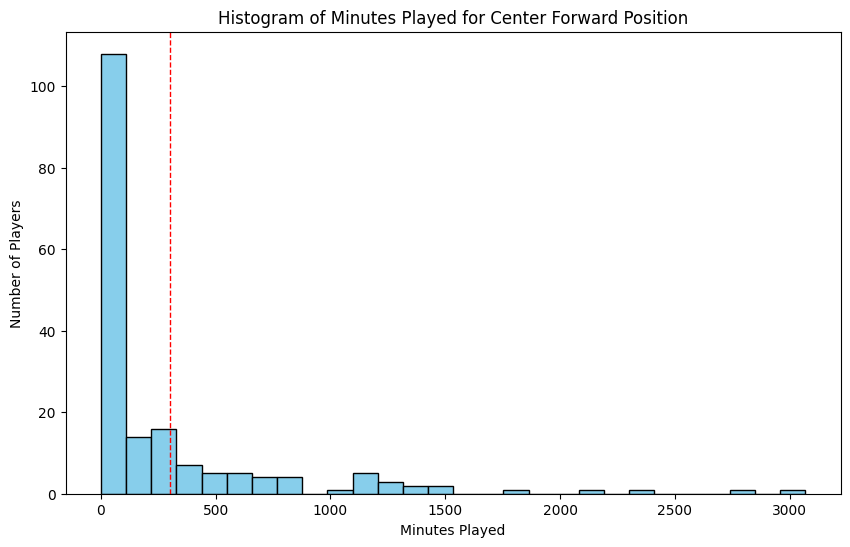

In [15]:
# Histogram of minutes played per for right winger position
df_pos = df_time_played[df_time_played['position'] == position_filter]
# df_pos = df_time_played[df_time_played['position'] == 'Center Attacking Midfield']
# df_pos = df_time_played[df_time_played['position'].isin(position_filter_list)]
print(f"Number of players plaing as {position_filter}: {len(df_pos)}")
print(f"Average minutes played for {position_filter}: {df_pos['minutes_played'].mean()}")
print(f"Number of {position_filter} with more than 300 minutes played: {len(df_pos[df_pos['minutes_played'] > 300])}")
plt.figure(figsize=(10,6))
plt.hist(df_pos['minutes_played'], bins='auto', color='skyblue', edgecolor='black')
plt.axvline(300, color='red', linestyle='dashed', linewidth=1)
plt.title(f'Histogram of Minutes Played for {position_filter} Position')
plt.xlabel('Minutes Played')
plt.ylabel('Number of Players')
plt.show()

In [16]:
selected_player_ids = df_pos[df_pos['minutes_played'] > 300]['player_id'].tolist()
n_players = len(selected_player_ids)
print(f"Number of players with more than 300 minutes played as {position_filter}: {n_players}")

Number of players with more than 300 minutes played as Center Forward: 47


## Prepare xT created values

In [17]:
# Import the values
df_xT_pos = pd.read_parquet('../3-calculate-values/xT_ratings_resampled_full.parquet', engine='fastparquet')
df_xT_pos = df_xT_pos[df_xT_pos['position'] == position_filter].copy()
df_xT_pos = df_xT_pos[df_xT_pos['player_id'].isin(selected_player_ids)].copy()
df_xT_pos.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 391839 entries, 153 to 19605604
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   player_id         391839 non-null  float64
 1   position          391839 non-null  object 
 2   xT_sum_true       47 non-null      float64
 3   n_actions         391839 non-null  int64  
 4   n_x               391839 non-null  int64  
 5   n_y               391839 non-null  int64  
 6   model_type        391839 non-null  object 
 7   xT_sum_resampled  391792 non-null  float64
 8   sample_size       391792 non-null  float64
 9   i_bootstrap       391792 non-null  float64
 10  random_state      391792 non-null  float64
dtypes: float64(6), int64(3), object(2)
memory usage: 75.1 MB


In [18]:
# Split the true values and resampled values
df_xT_pos_true = df_xT_pos[df_xT_pos['xT_sum_true'].notnull()].copy()
df_xT_pos_resampled = df_xT_pos[df_xT_pos['xT_sum_true'].isnull()].copy()

print(f"Shape of true xT values: {df_xT_pos_true.shape}")
print(f"Shape of resampled xT values: {df_xT_pos_resampled.shape}")

Shape of true xT values: (47, 11)
Shape of resampled xT values: (391792, 11)


In [19]:
# Calculate the sum of xT created per player
xT_per_player_resampled = df_xT_pos_resampled.groupby(['player_id', 'position', 'n_x', 'n_y', 'sample_size', 'i_bootstrap'])['xT_sum_resampled'].sum().reset_index()

# Merge the playing time to the xT created
xT_per_player_resampled = xT_per_player_resampled.merge(
    df_time_played,
    on=['player_id', 'position'],
    how='left'
)

# Calculate xT added per 90 minutes
xT_per_player_resampled['xT_created_per90_resampled'] = (xT_per_player_resampled['xT_sum_resampled'] / xT_per_player_resampled['minutes_played']) * 90
xT_per_player_resampled.describe()


,player_id,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled
count,391792.000000,391792.0,391792.0,3.917920e+05,391792.000000,391792.000000,391792.000000,391792.000000
mean,33569.702128,16.0,12.0,8.675000e+05,520.500000,1.177894,938.589380,0.103902
std,96379.229493,0.0,0.0,1.240805e+06,300.799736,1.355180,642.598392,0.050110
min,3010.000000,16.0,12.0,1.000000e+05,0.000000,0.079420,313.451817,0.020178
25%,3451.000000,16.0,12.0,1.600000e+05,260.000000,0.453332,465.720300,0.071884
50%,4909.000000,16.0,12.0,3.050000e+05,520.500000,0.744111,723.212883,0.093602
75%,15689.000000,16.0,12.0,7.975000e+05,781.000000,1.081633,1275.857883,0.119667
max,401541.000000,16.0,12.0,4.000000e+06,1041.000000,8.762641,3069.067633,0.337434


In [20]:
df_xT_pos_true

,player_id,position,xT_sum_true,n_actions,n_x,n_y,model_type,xT_sum_resampled,sample_size,i_bootstrap,random_state
153,3010.0,Center Forward,2.927790,172,16,12,true,NaN,NaN,NaN,NaN
163,3018.0,Center Forward,2.498337,234,16,12,true,NaN,NaN,NaN,NaN
169,3020.0,Center Forward,0.253696,34,16,12,true,NaN,NaN,NaN,NaN
219,3038.0,Center Forward,5.720818,445,16,12,true,NaN,NaN,NaN,NaN
259,3111.0,Center Forward,0.466363,73,16,12,true,NaN,NaN,NaN,NaN
266,3114.0,Center Forward,2.081371,200,16,12,true,NaN,NaN,NaN,NaN
361,3179.0,Center Forward,0.725388,106,16,12,true,NaN,NaN,NaN,NaN
372,3184.0,Center Forward,0.939429,125,16,12,true,NaN,NaN,NaN,NaN
490,3246.0,Center Forward,0.521501,151,16,12,true,NaN,NaN,NaN,NaN
558,3357.0,Center Forward,0.253726,25,16,12,true,NaN,NaN,NaN,NaN


In [21]:
# Calculate the sum of xT created per player
xT_per_player_true = df_xT_pos_true.groupby(['player_id', 'position', 'n_x', 'n_y'])['xT_sum_true'].sum().reset_index()

# Merge the playing time to the xT created
xT_per_player_true = xT_per_player_true.merge(
    df_time_played,
    on=['player_id', 'position'],
    how='left'
)

# Calculate xT added per 90 minutes
xT_per_player_true['xT_created_per90_true'] = (xT_per_player_true['xT_sum_true'] / xT_per_player_true['minutes_played']) * 90
xT_per_player_true.describe()

,player_id,n_x,n_y,xT_sum_true,minutes_played,xT_created_per90_true
count,47.000000,47.0,47.0,47.000000,47.000000,47.000000
mean,33569.702128,16.0,12.0,1.164110,938.589380,0.102664
std,97421.073063,0.0,0.0,1.356306,649.544775,0.049885
min,3010.000000,16.0,12.0,0.167012,313.451817,0.031891
25%,3454.000000,16.0,12.0,0.445578,467.197542,0.071578
50%,4909.000000,16.0,12.0,0.725388,723.212883,0.093548
75%,13009.500000,16.0,12.0,1.040414,1229.150542,0.116893
max,401541.000000,16.0,12.0,7.136372,3069.067633,0.267346


In [22]:
xT_per_player_true

,player_id,position,n_x,n_y,xT_sum_true,minutes_played,xT_created_per90_true
0,3010.0,Center Forward,16,12,2.927790,1408.648833,0.187059
1,3018.0,Center Forward,16,12,2.498337,2099.285650,0.107108
2,3020.0,Center Forward,16,12,0.253696,313.451817,0.072843
3,3038.0,Center Forward,16,12,5.720818,3069.067633,0.167762
4,3111.0,Center Forward,16,12,0.466363,542.300000,0.077398
5,3114.0,Center Forward,16,12,2.081371,1395.452717,0.134238
6,3179.0,Center Forward,16,12,0.725388,1139.646283,0.057285
7,3184.0,Center Forward,16,12,0.939429,1275.857883,0.066268
8,3246.0,Center Forward,16,12,0.521501,1471.755817,0.031891
9,3357.0,Center Forward,16,12,0.253726,324.765250,0.070313


In [23]:
# Calculate the quartile of each player per model configuration
xT_per_player_resampled['xT_created_per90_quartile_resampled'] = xT_per_player_resampled.groupby(
    ['n_x', 'n_y', 'sample_size', 'i_bootstrap']
)['xT_created_per90_resampled'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop') + 1
)

xT_per_player_true['xT_created_per90_quartile_true'] = xT_per_player_true.groupby(
    ['n_x', 'n_y']
)['xT_created_per90_true'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop') + 1
)

xT_per_player_resampled

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4
...,...,...,...,...,...,...,...,...,...,...
391787,401541.0,Center Forward,16,12,4000000.0,1037.0,0.866440,1293.474233,0.060287,1
391788,401541.0,Center Forward,16,12,4000000.0,1038.0,0.862039,1293.474233,0.059981,1
391789,401541.0,Center Forward,16,12,4000000.0,1039.0,0.866294,1293.474233,0.060277,1
391790,401541.0,Center Forward,16,12,4000000.0,1040.0,0.874331,1293.474233,0.060836,1


In [43]:
xT_per_player_resampled['i_bootstrap'].nunique()

1042

In [24]:
# Note: should change the code to exclude shots ... (or check correctness)

In [25]:
# # Calculate the quartiles per model
# xT_per_player_resampled['quartile'] = pd.qcut(
#     xT_per_player_resampled['xT_created_per90'],
#     q=4,
#     labels=['Q1', 'Q2', 'Q3', 'Q4']
# )

# xT_per_player_true['quartile'] = pd.qcut(
#     xT_per_player_true['xT_created_per90'],
#     q=4,
#     labels=['Q1', 'Q2', 'Q3', 'Q4']
# )


In [26]:
# Calculate the differences between resampled an true values
xT_merged = xT_per_player_resampled.merge(
    xT_per_player_true[['player_id', 'n_x', 'n_y', 'xT_created_per90_true', 'xT_created_per90_quartile_true']],
    on=['player_id', 'n_x', 'n_y'],
    # suffixes=('_resampled', '_true')
    how='left',
)
xT_merged['quartile_changes'] = np.abs(xT_merged['xT_created_per90_quartile_resampled'] - xT_merged['xT_created_per90_quartile_true'])
xT_merged['incorrect_estimation'] = (xT_merged['xT_created_per90_quartile_resampled'] != xT_merged['xT_created_per90_quartile_true'])
xT_merged

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled,xT_created_per90_true,xT_created_per90_quartile_true,quartile_changes,incorrect_estimation
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4,0.187059,4,0,False
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4,0.187059,4,0,False
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4,0.187059,4,0,False
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4,0.187059,4,0,False
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4,0.187059,4,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391787,401541.0,Center Forward,16,12,4000000.0,1037.0,0.866440,1293.474233,0.060287,1,0.060179,1,0,False
391788,401541.0,Center Forward,16,12,4000000.0,1038.0,0.862039,1293.474233,0.059981,1,0.060179,1,0,False
391789,401541.0,Center Forward,16,12,4000000.0,1039.0,0.866294,1293.474233,0.060277,1,0.060179,1,0,False
391790,401541.0,Center Forward,16,12,4000000.0,1040.0,0.874331,1293.474233,0.060836,1,0.060179,1,0,False


## Add the model error info

In [27]:
# Load both old and new error dataframes
df_errors = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat_max_error_full.csv').rename(columns={'sample_size': 'N'})
print(df_errors.shape)

# Filter on the 16x12 grid
df_errors = df_errors[(df_errors['n_x'] == 16) & (df_errors['n_y'] == 12)].copy()

df_errors = df_errors[['n_x', 'n_y', 'N', 'i_bootstrap', 'random_state', 'xT_error_inf_norm']].rename(columns={'N': 'sample_size'})
df_errors.head()

(80000, 21)


,n_x,n_y,sample_size,i_bootstrap,random_state,xT_error_inf_norm
0,16,12,4000000,0,15760042,0.017879
1,16,12,4000000,1,15760043,0.009632
2,16,12,4000000,2,15760044,0.007746
3,16,12,4000000,3,15760045,0.016141
4,16,12,4000000,4,15760046,0.008392


In [28]:
df_errors.shape

(80000, 6)

In [29]:
xT_merged = xT_merged.merge(
    df_errors,
    on=['n_x', 'n_y', 'sample_size', 'i_bootstrap'],
    how='left'
)
xT_merged

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled,xT_created_per90_true,xT_created_per90_quartile_true,quartile_changes,incorrect_estimation,random_state,xT_error_inf_norm
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4,0.187059,4,0,False,11860042,0.056519
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4,0.187059,4,0,False,11860043,0.025715
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4,0.187059,4,0,False,11860044,0.075247
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4,0.187059,4,0,False,11860045,0.088615
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4,0.187059,4,0,False,11860046,0.057338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391787,401541.0,Center Forward,16,12,4000000.0,1037.0,0.866440,1293.474233,0.060287,1,0.060179,1,0,False,15761079,0.011730
391788,401541.0,Center Forward,16,12,4000000.0,1038.0,0.862039,1293.474233,0.059981,1,0.060179,1,0,False,15761080,0.006953
391789,401541.0,Center Forward,16,12,4000000.0,1039.0,0.866294,1293.474233,0.060277,1,0.060179,1,0,False,15761081,0.011360
391790,401541.0,Center Forward,16,12,4000000.0,1040.0,0.874331,1293.474233,0.060836,1,0.060179,1,0,False,15761082,0.009075


# Calculate number of quantile changes per model

In [30]:
model_mistakes = xT_merged.groupby(
    ['n_x', 'n_y', 'sample_size', 'i_bootstrap']).agg(
        max_quartile_change = ('quartile_changes', 'max'),
        n_quartile_changes = ('incorrect_estimation', 'sum'),
        model_error = ('xT_error_inf_norm', 'first'),
    ).reset_index()
model_mistakes

,n_x,n_y,sample_size,i_bootstrap,max_quartile_change,n_quartile_changes,model_error
0,16,12,100000.0,0.0,1,12,0.056519
1,16,12,100000.0,1.0,1,6,0.025715
2,16,12,100000.0,2.0,1,12,0.075247
3,16,12,100000.0,3.0,1,4,0.088615
4,16,12,100000.0,4.0,1,6,0.057338
...,...,...,...,...,...,...,...
8331,16,12,4000000.0,1037.0,0,0,0.011730
8332,16,12,4000000.0,1038.0,0,0,0.006953
8333,16,12,4000000.0,1039.0,0,0,0.011360
8334,16,12,4000000.0,1040.0,1,2,0.009075


In [31]:
model_mistakes['max_quartile_change'].max()

np.int64(2)

# Investigate results

In [32]:
model_mistakes['n_quartile_changes'].value_counts()

n_quartile_changes
4     1778
2     1730
6     1664
0     1235
8      934
10     484
12     170
9       82
11      66
14      62
7       48
13      27
5       18
15      14
16      13
18       4
3        4
17       3
Name: count, dtype: int64

In [33]:
n_players

47

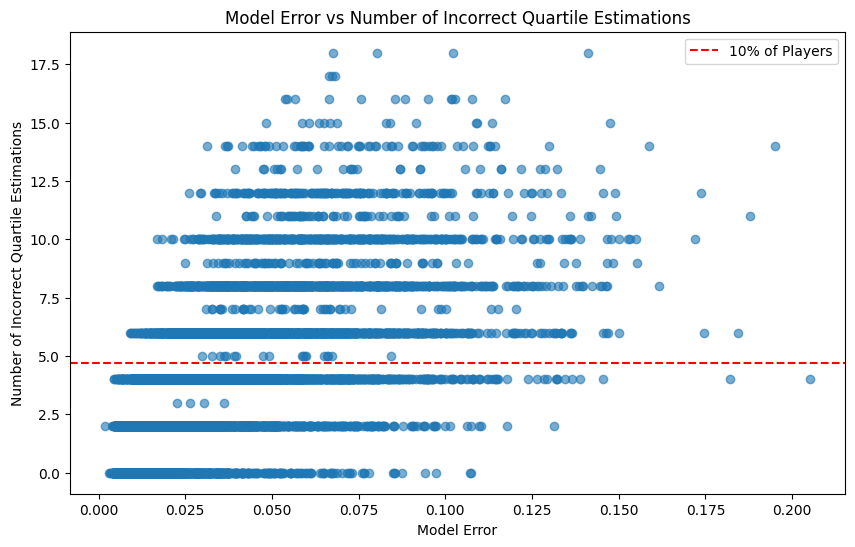

In [34]:
# Plot the size of the model error vs the n_quartile_changes
plt.figure(figsize=(10,6))
plt.scatter(model_mistakes['model_error'], model_mistakes['n_quartile_changes'], alpha=0.6)
plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of Players')
plt.title('Model Error vs Number of Incorrect Quartile Estimations')
plt.xlabel('Model Error')
plt.ylabel('Number of Incorrect Quartile Estimations')
plt.legend()
plt.show()

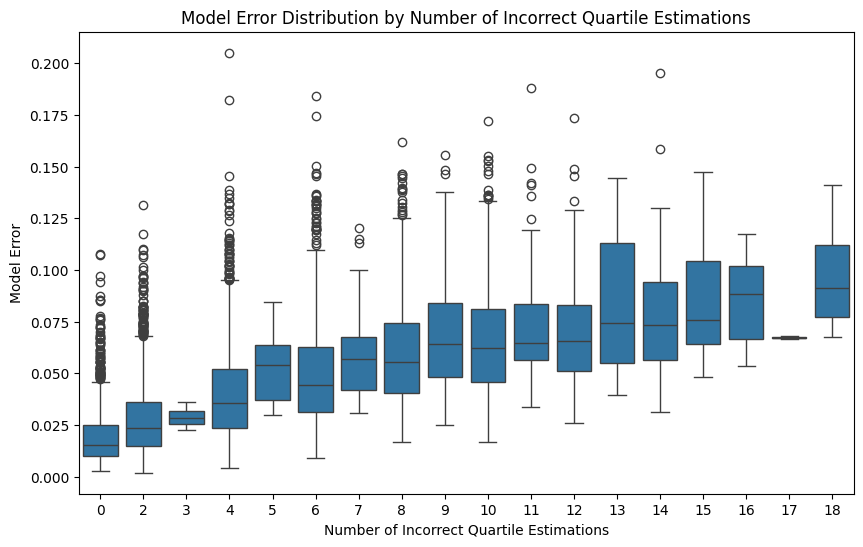

In [35]:
# Apply quantile estimation to the number of incorrect estimations
plt.figure(figsize=(10,6))
sns.boxplot(x='n_quartile_changes', y='model_error', data=model_mistakes)
plt.title('Model Error Distribution by Number of Incorrect Quartile Estimations')
plt.xlabel('Number of Incorrect Quartile Estimations')
plt.ylabel('Model Error')
plt.show()

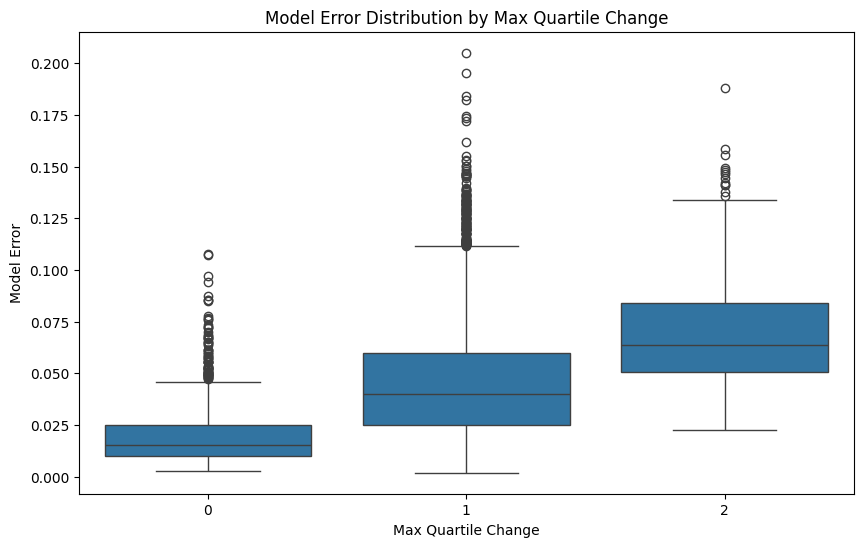

In [36]:
# Make boxplots of quartile changes vs model error
plt.figure(figsize=(10,6))
sns.boxplot(x='max_quartile_change', y='model_error', data=model_mistakes)
plt.title('Model Error Distribution by Max Quartile Change')
plt.xlabel('Max Quartile Change')
plt.ylabel('Model Error')
plt.show()

## Inspect quartiles

In [37]:
# choose quantiles of interest
qs = [0.10, 0.25, 0.50, 0.75, 0.90]

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=30,        # number of bins
    duplicates='drop'
)

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid

print(conditional_quantiles)

                    0.1  0.25  0.5   0.75   0.9  bin_center
error_bin                                                  
(0.00093, 0.00796]  0.0   0.0  0.0   2.00   2.0    0.004445
(0.00796, 0.00999]  0.0   0.0  1.0   2.00   4.0    0.008975
(0.00999, 0.012]    0.0   0.0  2.0   2.00   4.0    0.010995
(0.012, 0.0139]     0.0   0.0  2.0   2.00   4.0    0.012950
(0.0139, 0.0159]    0.0   0.0  2.0   4.00   4.0    0.014900
(0.0159, 0.0178]    0.0   0.0  2.0   4.00   4.6    0.016850
(0.0178, 0.0198]    0.0   0.0  2.0   4.00   6.0    0.018800
(0.0198, 0.0218]    0.0   2.0  2.0   4.00   6.0    0.020800
(0.0218, 0.0242]    0.0   2.0  2.0   6.00   6.0    0.023000
(0.0242, 0.0262]    0.0   2.0  4.0   6.00   6.0    0.025200
(0.0262, 0.028]     0.0   2.0  4.0   6.00   6.0    0.027100
(0.028, 0.0301]     0.0   2.0  4.0   6.00   6.6    0.029050
(0.0301, 0.0323]    0.0   2.0  4.0   6.00   7.4    0.031200
(0.0323, 0.0344]    2.0   2.0  4.0   6.00   8.0    0.033350
(0.0344, 0.0366]    0.0   2.0  4.0   6.0

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_5944\598536396.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']


In [38]:
conditional_quantiles[conditional_quantiles[0.90] > 0.1*n_players]['bin_center'].min()

np.float64(0.0188)

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_5944\2569390207.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']


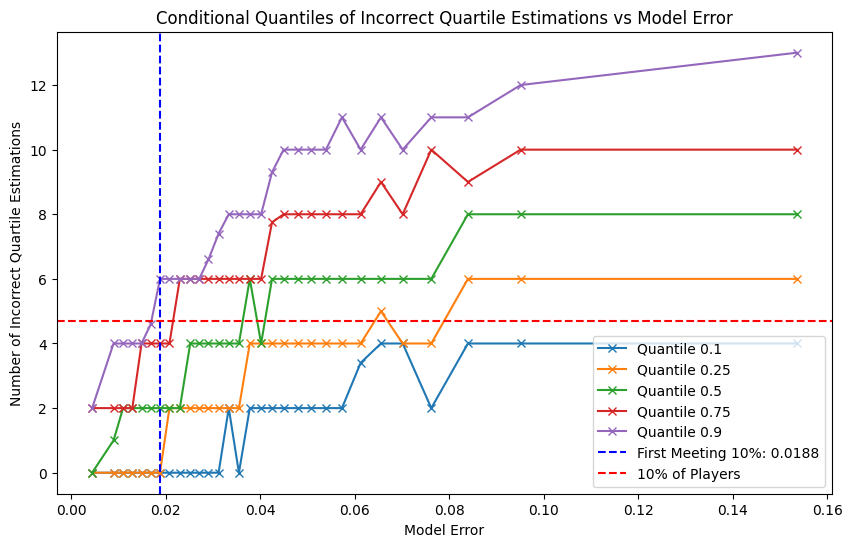

In [39]:
# choose quantiles of interest
qs = [0.10, 0.25, 0.50, 0.75, 0.90]

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=30,        # number of bins
    duplicates='drop'
)

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid


# Plot the conditional quantiles
plt.figure(figsize=(10, 6))
for q in qs:
    plt.plot(
        conditional_quantiles.index.categories.mid,
        conditional_quantiles[q],
        marker='x',
        label=f'Quantile {q}'
    )
# Plot a vertical line where 10% is met for the first time
# index_first_meeting_10_percent = conditional_quantiles[conditional_quantiles[0.90] > 0.1*n_players].argmin()
first_meeting_10_percent = conditional_quantiles[conditional_quantiles[0.90] > 0.1*n_players]['bin_center'].min()
# first_meeting_10_percent = conditional_quantiles.iloc[index_first_meeting_10_percent]['bin_center']
plt.axvline(first_meeting_10_percent, color='blue', linestyle='--', label=f'First Meeting 10%: {first_meeting_10_percent:.4f}')

plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of Players')
plt.title('Conditional Quantiles of Incorrect Quartile Estimations vs Model Error')
plt.xlabel('Model Error')
plt.ylabel('Number of Incorrect Quartile Estimations')
plt.legend()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_5944\2544412274.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']


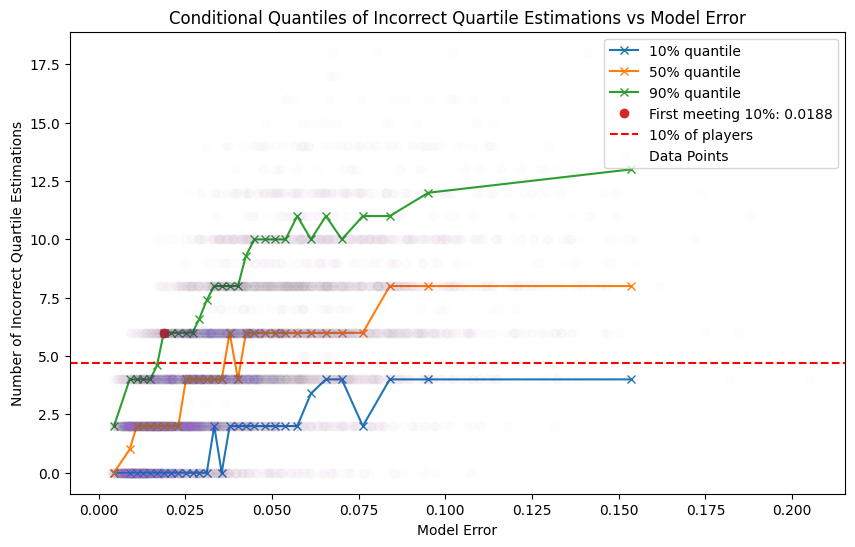

In [40]:
# choose quantiles of interest
qs = [0.10, 0.50, 0.90]

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=30,        # number of bins
    duplicates='drop'
)

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid


# Plot the conditional quantiles
plt.figure(figsize=(10, 6))
for q in qs:
    plt.plot(
        conditional_quantiles.index.categories.mid,
        conditional_quantiles[q],
        marker='x',
        label=f'{q*100:.0f}% quantile'
    )

first_meeting_10_percent = conditional_quantiles[conditional_quantiles[0.90] > 0.1*n_players]['bin_center'].min()
first_meeting_10_percent_y = conditional_quantiles[conditional_quantiles[0.90] > 0.1*n_players][0.90].min()
plt.plot(first_meeting_10_percent, first_meeting_10_percent_y, 'o', label=f'First meeting 10%: {first_meeting_10_percent:.4f}')
plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of players')

plt.plot(model_mistakes['model_error'], model_mistakes['n_quartile_changes'], 'o', alpha=0.008, label='Data Points')

plt.title('Conditional Quantiles of Incorrect Quartile Estimations vs Model Error')
plt.xlabel('Model Error')
plt.ylabel('Number of Incorrect Quartile Estimations')
plt.legend()
plt.show()

In [41]:
400*20

8000

Number of data points per bin:
error_bin
(0.00093, 0.00909]    417
(0.00909, 0.012]      417
(0.012, 0.0149]       417
(0.0149, 0.0178]      417
(0.0209, 0.0242]      417
(0.0242, 0.027]       417
(0.027, 0.0301]       417
(0.0334, 0.0366]      417
(0.0401, 0.0436]      417
(0.0366, 0.0401]      417
(0.0522, 0.0575]      417
(0.0479, 0.0522]      417
(0.0942, 0.205]       417
(0.0797, 0.0942]      417
(0.0575, 0.0635]      417
(0.0702, 0.0797]      417
(0.0301, 0.0334]      416
(0.0178, 0.0209]      416
(0.0436, 0.0479]      416
(0.0635, 0.0702]      416
Name: count, dtype: int64


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_5944\596035647.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_5944\596035647.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


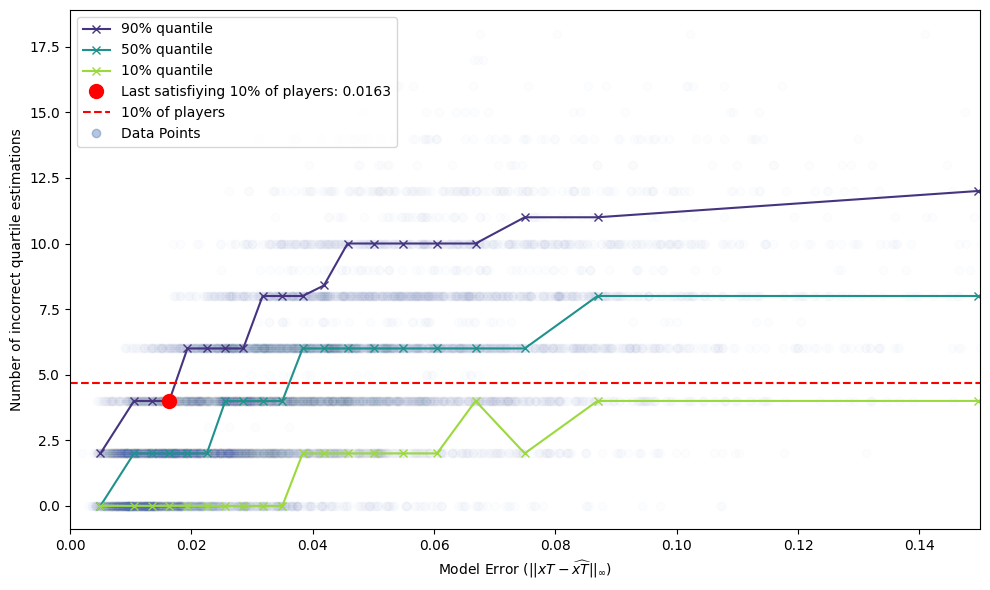

In [42]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.lines import Line2D

#### Estimate quantiles ####
# Define quartiles to plot
qs = [0.10, 0.50, 0.90]
quantile_4_threshold = 0.90
n_bins = 20

# Sort quantiles high -> low
qs_sorted = sorted(qs, reverse=True)

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=n_bins,        
)
print(f"Number of data points per bin:\n{model_mistakes['error_bin'].value_counts()}")

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid


#### Plot quantiles ####
# Colormap for quantiles
cmap = cm.get_cmap("viridis")
colors = cmap(np.linspace(0.15, 0.85, len(qs_sorted)))

plt.figure(figsize=(10, 6))

# Plot conditional quantiles
for q, color in zip(qs_sorted, colors):
    plt.plot(
        conditional_quantiles['bin_center'],
        conditional_quantiles[q],
        marker='x',
        color=color,
        label=f'{q*100:.0f}% quantile'
    )

# First meeting marker (larger, different color)
first_meeting_10_percent = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players]['bin_center'].max()
first_meeting_10_percent_y = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players][quantile_4_threshold].max()
plt.plot(
    first_meeting_10_percent,
    first_meeting_10_percent_y,
    marker='o',
    linewidth=0,
    markersize=10,
    color='red',
    label=f'Last satisfiying 10% of players: {first_meeting_10_percent:.4f}'
)

# Horizontal threshold line
plt.axhline(
    n_players * 0.10,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='10% of players'
)

# Scatter data points (low alpha in plot)
plt.scatter(
    model_mistakes['model_error'],
    model_mistakes['n_quartile_changes'],
    alpha=0.01,
    # s=10,
    color="#4C72B0",
)

# ---- Custom legend entry for data points with higher alpha ----
legend_elements = plt.gca().get_legend_handles_labels()

legend_elements[0].append(
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color="#4C72B0",
        alpha=0.4,     # higher alpha in legend
        label='Data Points'
    )
)
legend_elements[1].append('Data Points')

# plt.title('Conditional Quantiles of Incorrect Quartile Estimations vs Model Error')
plt.xlabel(r'Model Error ($||xT-\widehat{xT}||_{\infty}$)')
plt.ylabel('Number of incorrect quartile estimations')
plt.legend(*legend_elements)
plt.tight_layout()
plt.xlim(0, 0.15)
plt.show()


 18%|█▊        | 1425/7901 [00:02<00:09, 697.75it/s]

First time 90% quantile is above 10% of players incorrect at model error: 0.01584229700989615


100%|██████████| 7901/7901 [00:14<00:00, 544.92it/s]


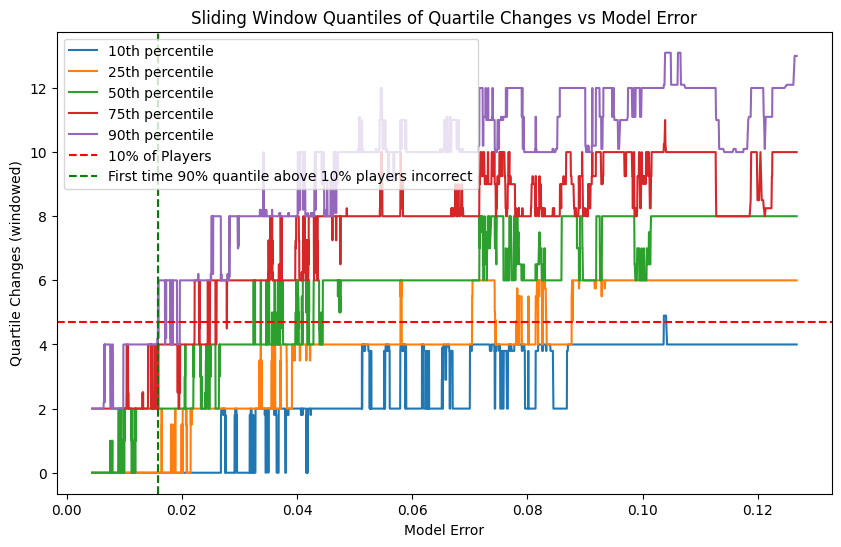

In [109]:
# Estimate the quantiles of the incorrect estimations using a moving window for the model error
model_mistakes.sort_values('model_error', inplace=True)

window_size = 100   # adjustable, e.g. number of points or a range width
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

results = {q: [] for q in quantiles}
centers = []
first_time_above_10pct = None

# sliding window over sorted model_error
for i in tqdm(range(len(model_mistakes) - window_size + 1)):
    # print(0, i-int(window_size/2), len(model_mistakes), i+int(window_size/2))
    # print(max(0, i - int(window_size/2)), min(len(model_mistakes), i+int(window_size/2)))
    window = model_mistakes.iloc[max(0, i - int(window_size/2)):min(len(model_mistakes), i+int(window_size/2))]
    centers.append(window['model_error'].median())
    for q in quantiles:
        results[q].append(window['n_quartile_changes'].quantile(q))
        if q == 0.90 and first_time_above_10pct is None and results[q][-1] > n_players * 0.10:
            first_time_above_10pct = centers[-1]
            print(f"First time 90% quantile is above 10% of players incorrect at model error: {first_time_above_10pct}")

# convert to dataframe for easy plotting
qdf = pd.DataFrame(results, index=centers)

# ---- plotting ----
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(qdf.index, qdf[q], label=f"{int(q*100)}th percentile")

plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of Players')
if first_time_above_10pct is not None:
    plt.axvline(first_time_above_10pct, color='green', linestyle='--', label='First time 90% quantile above 10% players incorrect')

plt.xlabel("Model Error")
plt.ylabel("Quartile Changes (windowed)")
plt.title("Sliding Window Quantiles of Quartile Changes vs Model Error")
plt.legend()
plt.show()

 18%|█▊        | 1442/8000 [00:02<00:12, 543.16it/s]

First time 90% quantile is above 10% of players incorrect at model error: 0.01584229700989615


100%|██████████| 8000/8000 [00:12<00:00, 618.51it/s]


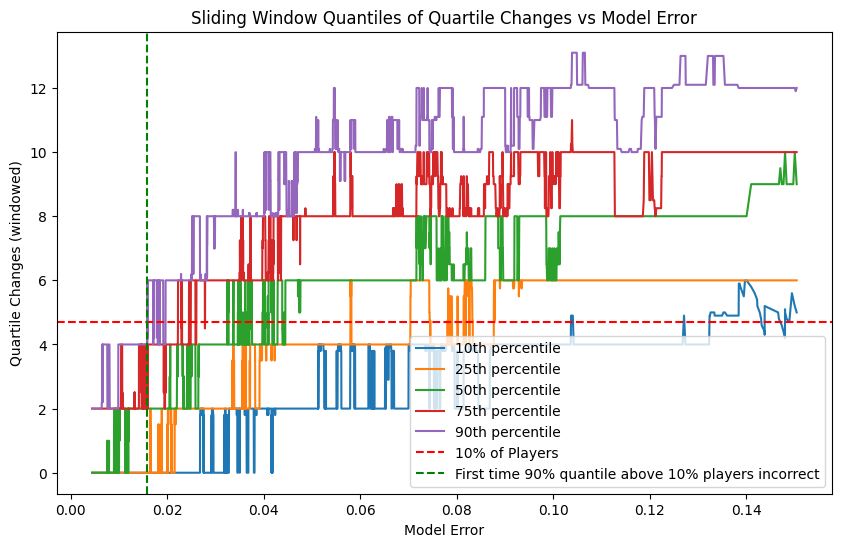

In [110]:
# Estimate the quantiles of the incorrect estimations using a moving window for the model error
model_mistakes.sort_values('model_error', inplace=True)

window_size = 100   # adjustable, e.g. number of points or a range width
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

results = {q: [] for q in quantiles}
centers = []
first_time_above_10pct = None

# sliding window over sorted model_error
for i in tqdm(range(len(model_mistakes))):
    # print(0, i-int(window_size/2), len(model_mistakes), i+int(window_size/2))
    # print(max(0, i - int(window_size/2)), min(len(model_mistakes), i+int(window_size/2)))
    window = model_mistakes.iloc[max(0, i - int(window_size/2)):min(len(model_mistakes), i+int(window_size/2))]
    centers.append(window['model_error'].median())
    for q in quantiles:
        results[q].append(window['n_quartile_changes'].quantile(q))
        if q == 0.90 and first_time_above_10pct is None and results[q][-1] > n_players * 0.10:
            first_time_above_10pct = centers[-1]
            print(f"First time 90% quantile is above 10% of players incorrect at model error: {first_time_above_10pct}")

# convert to dataframe for easy plotting
qdf = pd.DataFrame(results, index=centers)

# ---- plotting ----
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(qdf.index, qdf[q], label=f"{int(q*100)}th percentile")

plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of Players')
if first_time_above_10pct is not None:
    plt.axvline(first_time_above_10pct, color='green', linestyle='--', label='First time 90% quantile above 10% players incorrect')

plt.xlabel("Model Error")
plt.ylabel("Quartile Changes (windowed)")
plt.title("Sliding Window Quantiles of Quartile Changes vs Model Error")
plt.legend()
plt.show()

 50%|█████     | 50/100 [00:00<00:00, 257.03it/s]

First time 90% quantile is above 10% of players incorrect at model error: 0.017785829853156108


100%|██████████| 100/100 [00:00<00:00, 179.22it/s]


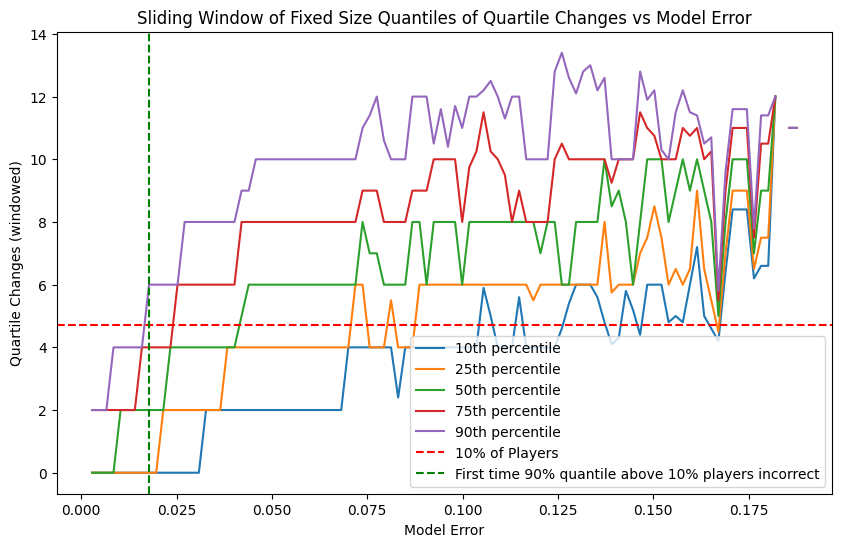

In [108]:
# Estimate the quantiles of the incorrect estimations using a moving window of fixed size for the model error
model_mistakes.sort_values('model_error', inplace=True)

window_size = 0.005   # adjustable, e.g. number of points or a range width
N_points = 100
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

results = {q: [] for q in quantiles}
centers = []

first_time_above_10pct = None

# sliding window over sorted model_error
for i in tqdm(range(N_points)):
    center = i / (N_points - 1) * (model_mistakes['model_error'].max() - model_mistakes['model_error'].min()) + model_mistakes['model_error'].min()
    left_bound = center - window_size / 2
    right_bound = center + window_size / 2
    window = model_mistakes[(left_bound < model_mistakes['model_error']) & (model_mistakes['model_error'] <= right_bound)]
    centers.append(center)
    for q in quantiles:
        results[q].append(window['n_quartile_changes'].quantile(q))

        if q == 0.90 and first_time_above_10pct is None and results[q][-1] > n_players * 0.10:
            first_time_above_10pct = center
            print(f"First time 90% quantile is above 10% of players incorrect at model error: {first_time_above_10pct}")
            
# convert to dataframe for easy plotting
qdf = pd.DataFrame(results, index=centers)

# ---- plotting ----
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(qdf.index, qdf[q], label=f"{int(q*100)}th percentile")

plt.axhline(n_players*0.10, color='red', linestyle='--', label='10% of Players')
if first_time_above_10pct is not None:
    plt.axvline(first_time_above_10pct, color='green', linestyle='--', label='First time 90% quantile above 10% players incorrect')
plt.xlabel("Model Error")
plt.ylabel("Quartile Changes (windowed)")
plt.title("Sliding Window of Fixed Size Quantiles of Quartile Changes vs Model Error")
plt.legend()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31820\3622646962.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_quantiles = model_mistakes.groupby('error_bin')['n_quartile_changes'].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()


<Figure size 1000x600 with 0 Axes>

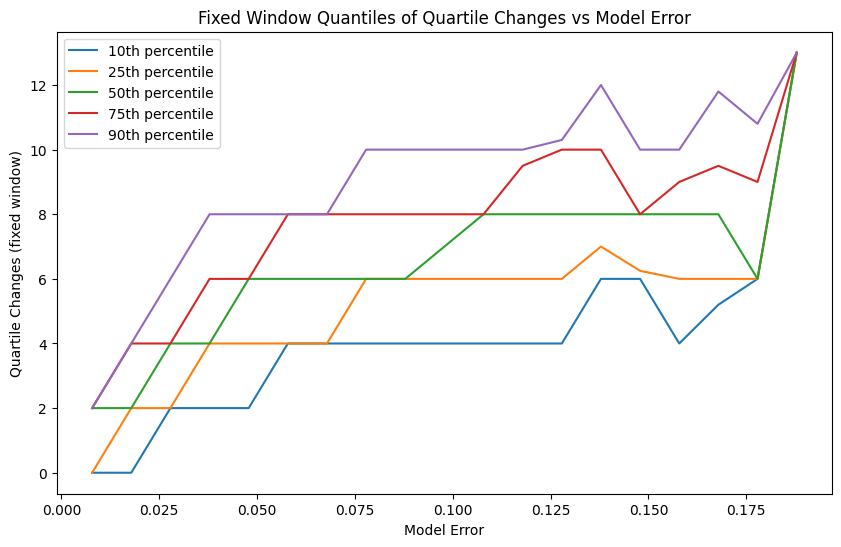

In [ ]:
# Now make one that has a fixed window size of model error 
plt.figure(figsize=(10,6))  
# Define fixed window size
window_width = 0.01 # Adjust as needed
# Create bins based on the fixed window size
bins = np.arange(model_mistakes['model_error'].min(), model_mistakes['model_error'].max() + window_width, window_width)
model_mistakes['error_bin'] = pd.cut(model_mistakes['model_error'], bins=bins)
# Calculate quantiles within each bin
binned_quantiles = model_mistakes.groupby('error_bin')['n_quartile_changes'].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()
# Calculate bin centers for plotting
bin_centers = bins[:-1] + window_width / 2
plt.figure(figsize=(10, 6))
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    plt.plot(bin_centers, binned_quantiles[q], label=f"{int(q*100)}th percentile")

plt.xlabel("Model Error")
plt.ylabel("Quartile Changes (fixed window)")
plt.title("Fixed Window Quantiles of Quartile Changes vs Model Error")
plt.legend()
plt.show()


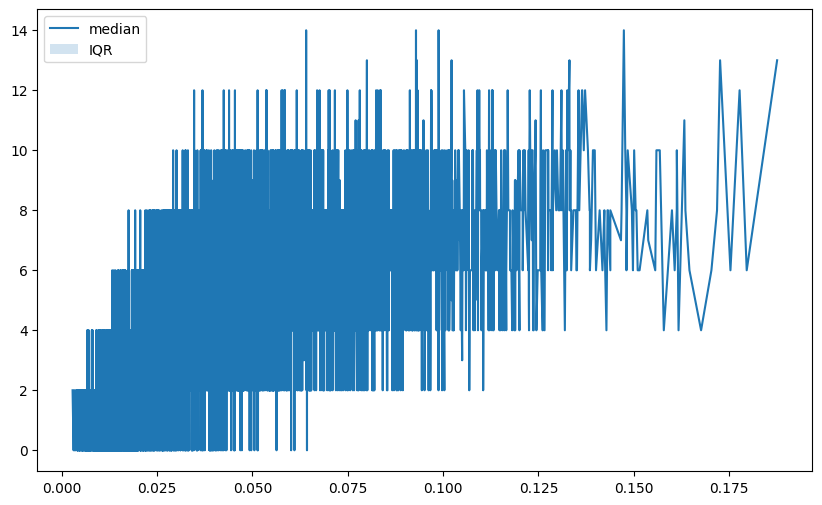

In [ ]:
# Now make one with seaborn's quantile estimation
plt.figure(figsize=(10,6))
qs = model_mistakes.groupby('model_error')['n_quartile_changes'] \
        .quantile([0.25, 0.5, 0.75]).unstack()

plt.plot(qs.index, qs[0.5], label='median')
plt.fill_between(qs.index, qs[0.25], qs[0.75], alpha=0.2, label='IQR')
plt.legend()

In [ ]:
# Now take the other way around: for a given number of incorrect estimations, what is the distribution of model errors?
# Plot it with quantile estimation


In [ ]:
# Plot it with quantile estimation
# Plot the size of the model error vs the n_quantile_changes
plt.figure(figsize=(10,6))


# Only take into account segments of players playing as center attacking midfielders

# Filter on midfielders with at least 300 minutes

In [19]:
filtered_player_ids = filtered_players['player_id']
mask = df_events['player_id'].isin(filtered_player_ids)
df_events_filtered = df_events[mask].copy()
df_events_filtered

,x,y,possession_kept,possession_length,chain_length,previous_deleted,match_id,period,player_id,type,...,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id,shot,goal
index,,,,,,,,,,,,,,,,,,,,,
8,37.6250,34.085,True,0,0,True,3829413,1,3026.0,Pass,...,Ground Pass,NaN,Carry,26.0750,28.305,NaN,131.0,3956.0,False,False
1797,26.0750,28.305,True,1,1,False,3829413,1,3956.0,Carry,...,None,NaN,Pass,25.6375,30.260,NaN,131.0,3956.0,False,False
9,25.6375,30.260,True,2,2,False,3829413,1,3956.0,Pass,...,Ground Pass,NaN,Carry,24.2375,45.220,NaN,131.0,3295.0,False,False
1798,24.2375,45.220,True,3,3,False,3829413,1,3295.0,Carry,...,None,NaN,Pass,27.7375,49.045,NaN,131.0,3295.0,False,False
10,27.7375,49.045,True,4,4,False,3829413,1,3295.0,Pass,...,Ground Pass,NaN,Pass,31.0625,38.080,NaN,131.0,3026.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2630,13.2125,30.685,True,15,1,False,3901263,2,40528.0,Carry,...,None,NaN,Pass,13.2125,30.685,NaN,2736.0,40528.0,False,False
977,13.2125,30.685,False,16,0,False,3901263,2,40528.0,Pass,...,High Pass,NaN,Carry,63.7000,31.365,1.0,134.0,40699.0,False,False
2631,63.7000,31.365,True,17,1,False,3901263,2,40699.0,Carry,...,None,1.0,Carry,66.9375,35.020,1.0,134.0,40699.0,False,False


## Apply ratings from the true model 16x12

In [ ]:
# Get necessary columns
df_events_filtered['shot'] = ~df_events_filtered['shot_outcome'].isna()
df_events_filtered['goal'] = df_events_filtered['shot_outcome'] == 'Goal'

# Apply ratings
df_events_filtered = xT_true_16x12.quantify_action_quality(df_events_filtered)
# Filter for positive xT actions
df_positive = df_events_filtered[df_events_filtered['action_xT'] > 0]
df_positive = df_positive.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_midfielders = df_positive[df_positive['main_position'] == 'midfielder']

In [ ]:
# df_positive_midfielders.head()

In [ ]:
# Aggregate xT ratings for midfielders
xT_ratings = df_positive.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
xT_ratings['xT_per_90'] = xT_ratings['xT_sum'] / xT_ratings['Minutes'] * 90
xT_ratings['Quartile'] = pd.qcut(xT_ratings['xT_per_90'], 4, labels=False) + 1
xT_ratings.head()

NameError: name 'df_positive_midfielders' is not defined

# Perform simulations

In [21]:
# Simulation parameters
N_bootstrap = 10_000
thetas = np.linspace(0.001, 0.005)

In [22]:
# Prepare data for bootstrapping
xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = xT_ratings['Quartile'].values
original_ratings = xT_ratings['xT_per_90'].values
number_of_actions = xT_ratings['action_count'].values
number_of_minutes = xT_ratings['Minutes'].values
n_players = len(original_ratings)

## Find cut-off point error distribution

The student t distribution is most suitable because of the more heavy tails. We would like the relationship between the maximal errror and the average error to be the same. Therefore, we will now try to find the cut-off point to get this done. We can then rescale the distribution to have the correct maximal error.

In [35]:
# Mean error/max error
mean_max_ratio = 0.0158860

In [36]:
cut_off_points = np.linspace(0.001, 300, 2000)
mean_max_ratios = np.zeros(len(cut_off_points))

np.random.seed(42)

for i in tqdm(range(len(cut_off_points))):
    cut_off_value = cut_off_points[i]

    samples = np.random.standard_t(size = 1_000_000, df=1)
    samples[samples > cut_off_value] = cut_off_value
    samples[samples < -cut_off_value] = -cut_off_value
    
    mean_max_ratios[i] = np.abs(samples).mean()/np.abs(samples).max()

100%|██████████| 2000/2000 [02:57<00:00, 11.26it/s]


In [37]:
cut_off_factor = cut_off_points[np.argmin(np.abs(mean_max_ratios - mean_max_ratio))]
cut_off_factor

np.float64(263.5318874437218)

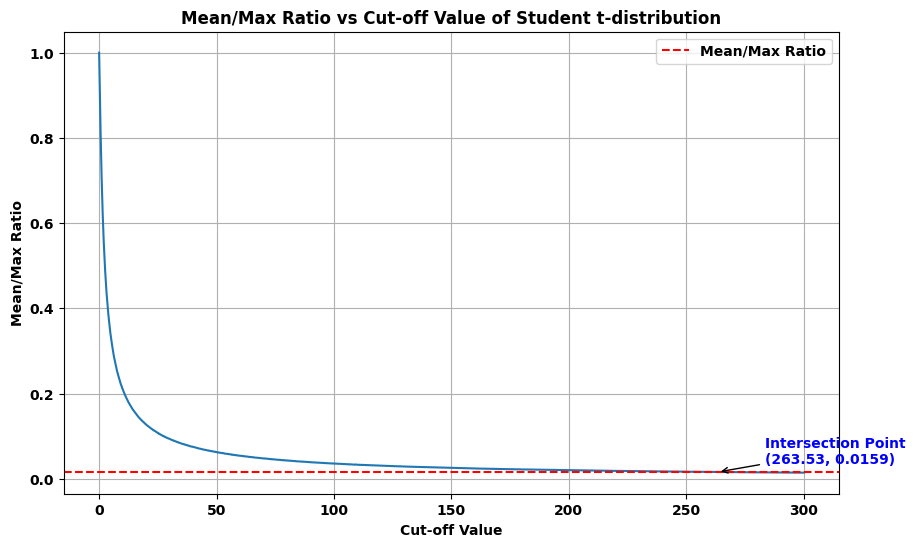

In [38]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(cut_off_points, mean_max_ratios)
plt.axhline(y=mean_max_ratio, color='r', linestyle='--', label='Mean/Max Ratio')
# Annotate intersecting point
intersection_idx = np.argmin(np.abs(mean_max_ratios - mean_max_ratio))
intersection_x = cut_off_points[intersection_idx]
intersection_y = mean_max_ratios[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.2f}, {intersection_y:.4f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 20, intersection_y + 0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')
plt.legend()
plt.title('Mean/Max Ratio vs Cut-off Value of Student t-distribution')
plt.xlabel('Cut-off Value')
plt.ylabel('Mean/Max Ratio')
plt.grid()
plt.show()


We can see that the cut-off point should be 269. We will now plot the resulting distribution.

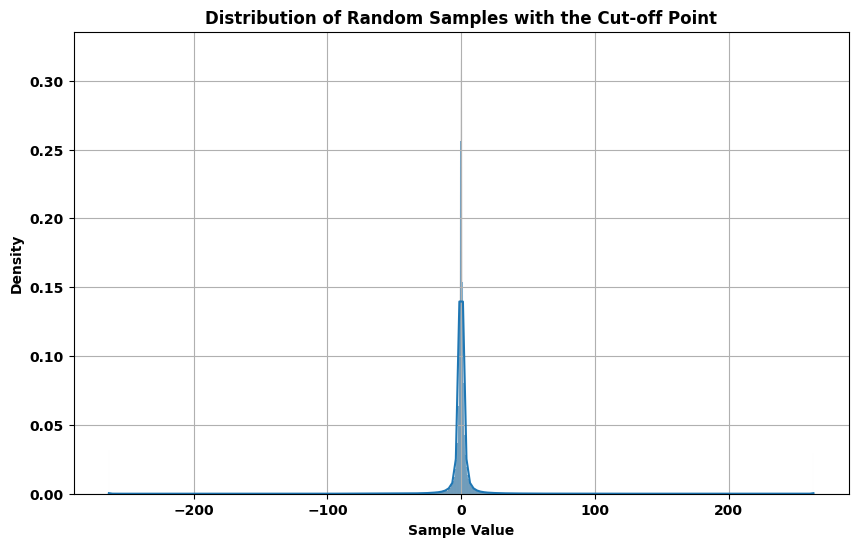

The mean/max ratio is 0.015938353036344416 with max error 263.5318874437218.


In [39]:
np.random.seed(42)

samples = np.random.standard_t(size = 1_000_000, df=1)
samples[samples > cut_off_factor] = cut_off_factor
samples[samples < -cut_off_factor] = -cut_off_factor

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

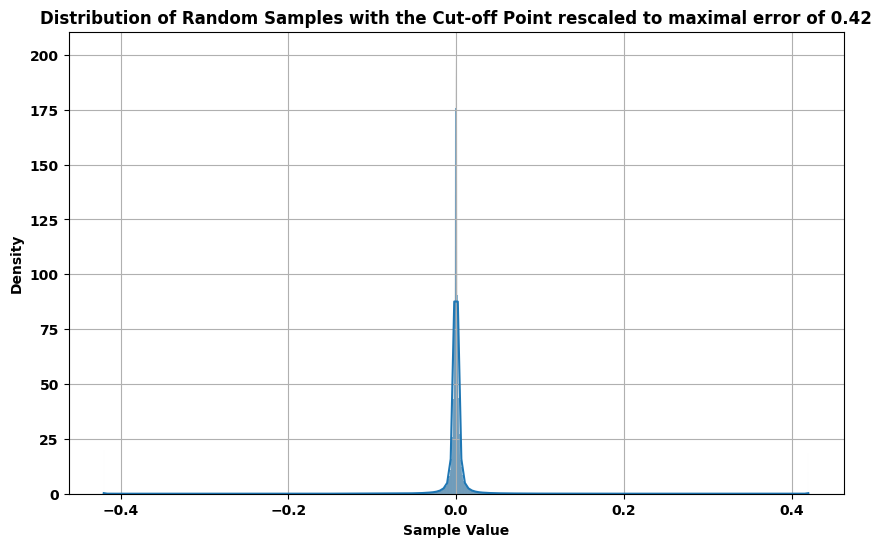

The mean/max ratio is 0.015938353036344433 with max error 0.42.


In [40]:
np.random.seed(42)

max_error = 0.42

samples = np.random.standard_t(size = 1_000_000, df=1) * max_error / cut_off_factor
samples[samples > max_error] = max_error
samples[samples < -max_error] = -max_error

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point rescaled to maximal error of 0.42')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

# Perform simulations on full in-game set of players

In [17]:
all_xT_ratings = df_positive.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
all_xT_ratings['xT_per_90'] = all_xT_ratings['xT_sum'] / all_xT_ratings['Minutes'] * 90
all_xT_ratings['Quartile'] = pd.qcut(all_xT_ratings['xT_per_90'], 4, labels=False) + 1
field_player_xT_ratings = all_xT_ratings[all_xT_ratings['main_position'] != 'Goalkeeper'].copy()
field_player_xT_ratings.head()

,player_id,xT_sum,action_count,Minutes,main_position,xT_per_90,Quartile
0,2954.0,0.725121,124,349,midfielder,0.186994,3
1,2988.0,1.403322,102,332,attacker,0.380419,4
2,2999.0,0.522738,275,415,defender,0.113365,2
3,3009.0,0.765843,81,415,attacker,0.166086,3
4,3026.0,0.445377,144,321,defender,0.124872,3


In [16]:
# Prepare data for bootstrapping
field_player_xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = field_player_xT_ratings['Quartile'].values
original_ratings = field_player_xT_ratings['xT_per_90'].values
number_of_actions = field_player_xT_ratings['action_count'].values
number_of_minutes = field_player_xT_ratings['Minutes'].values
n_players = len(original_ratings)

## Quickly simulate for general range of values

In [54]:
# Define range of max errors and number of bootstraps
N_bootstrap = 10_000
max_errors = np.linspace(0.1, 0.01, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [26:40<00:00, 32.00s/it]


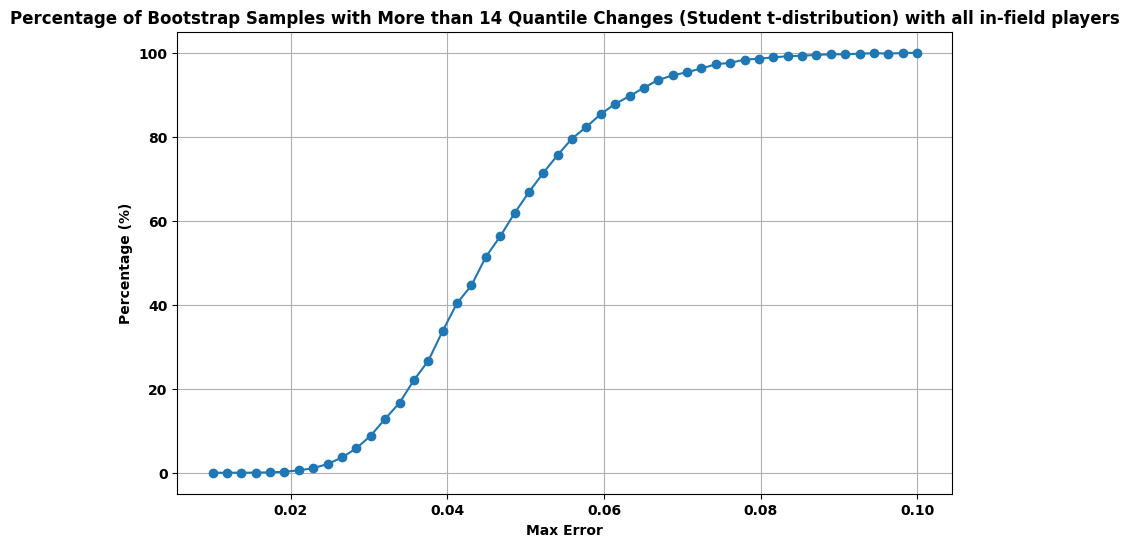

In [55]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution) with all in-field players')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

## Thoroughly simulate for specific range of values

In [56]:
# Define range of max errors and number of bootstraps
N_bootstrap = 100_000
max_errors = np.linspace(0.02, 0.035, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [6:45:06<00:00, 486.12s/it]   


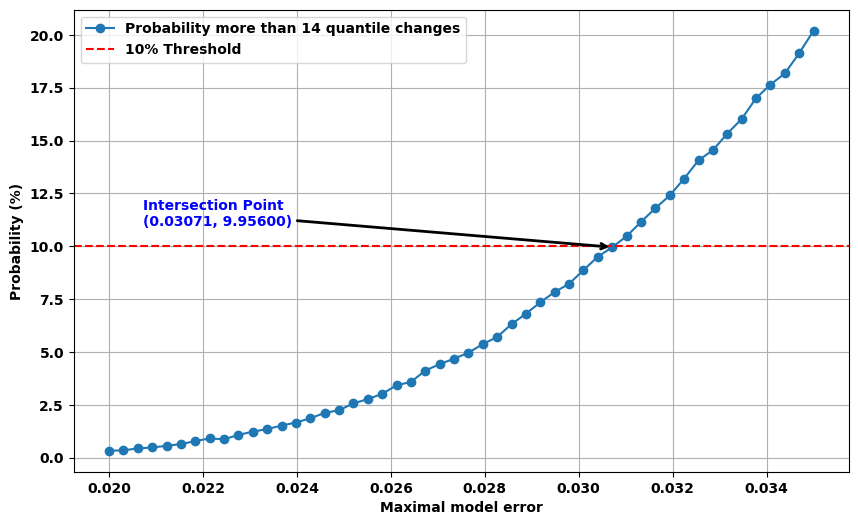

In [63]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Probability more than 14 quantile changes')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x - 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=2.0),
             fontsize=10, color='blue')

# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Maximal model error')
plt.ylabel('Probability (%)')
plt.legend()
plt.grid()
plt.show()

In [61]:
print(intersection_x, intersection_y)

0.030714285714285715 9.956
